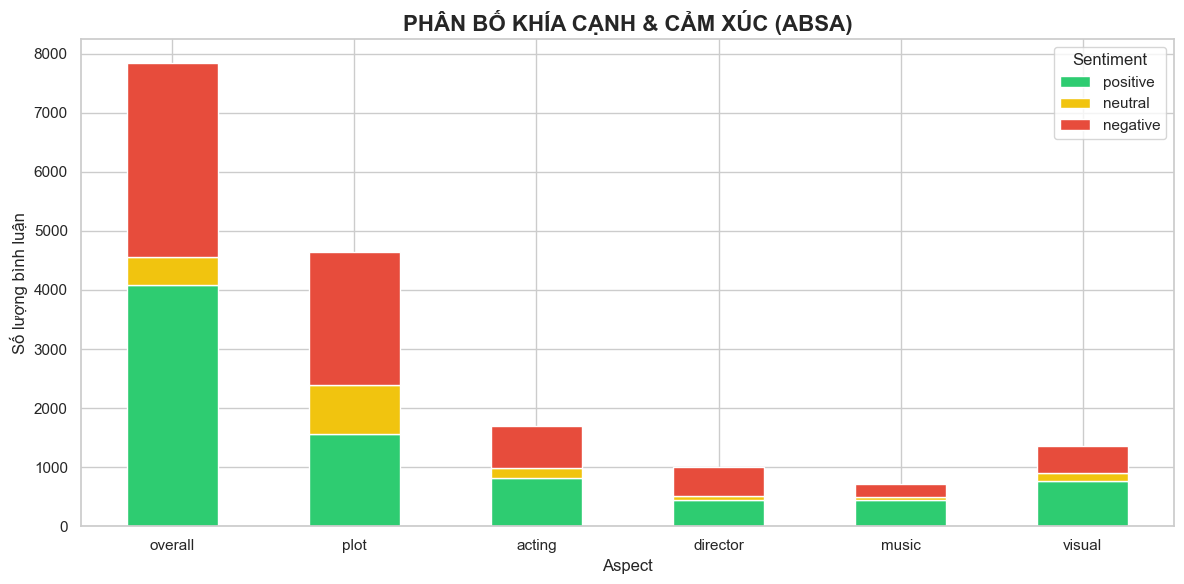

THỐNG KÊ ABSA DATASET (CLEAN VERSION)
Tổng số bình luận: 10683
Multi-aspect (>=2): 4498 (42.1%)
------------------------------------------------------------
CHI TIẾT TỪNG ASPECT:
OVERALL    | Total: 7852  | Pos: 4078  | Neu: 478   | Neg: 3296 
PLOT       | Total: 4649  | Pos: 1559  | Neu: 837   | Neg: 2253 
ACTING     | Total: 1699  | Pos: 819   | Neu: 159   | Neg: 721  
DIRECTOR   | Total: 1007  | Pos: 440   | Neu: 77    | Neg: 490  
MUSIC      | Total: 707   | Pos: 441   | Neu: 46    | Neg: 220  
VISUAL     | Total: 1362  | Pos: 763   | Neu: 137   | Neg: 462  


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 0. SETUP
# =========================
df = pd.read_csv("final.csv")
df_stats = df.copy()

target_aspects = ['overall', 'plot', 'acting', 'director', 'music', 'visual']

# chuẩn hoá toàn bộ aspect
df_stats[target_aspects] = df_stats[target_aspects].apply(
    lambda col: col.astype(str).str.lower().str.strip()
)

# =========================
# 1. THỐNG KÊ SENTIMENT THEO ASPECT
# =========================
aspect_counts = {}
sentiment_distribution = {
    'positive': [],
    'neutral': [],
    'negative': []
}

for col in target_aspects:
    counts = df_stats[col].value_counts()

    pos = counts.get('positive', 0)
    neu = counts.get('neutral', 0)
    neg = counts.get('negative', 0)

    aspect_counts[col] = pos + neu + neg

    sentiment_distribution['positive'].append(pos)
    sentiment_distribution['neutral'].append(neu)
    sentiment_distribution['negative'].append(neg)

df_sent_dist = pd.DataFrame(sentiment_distribution, index=target_aspects)

# =========================
# 2. VẼ BIỂU ĐỒ
# =========================
sns.set_theme(style="whitegrid")

df_sent_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['#2ecc71', '#f1c40f', '#e74c3c']
)

plt.title("PHÂN BỐ KHÍA CẠNH & CẢM XÚC (ABSA)", fontsize=16, fontweight='bold')
plt.xlabel("Aspect")
plt.ylabel("Số lượng bình luận")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

# =========================
# 3. OOD & MULTI-ASPECT (FIX CHUẨN)
# =========================

aspect_cols = target_aspects

# multi-aspect >= 2
multi_aspect_reviews = (
    (df_stats[aspect_cols] != "none")
    .sum(axis=1)
    .gt(1)
    .sum()
)

# =========================
# 4. PRINT REPORT
# =========================
print("=" * 60)
print("THỐNG KÊ ABSA DATASET (CLEAN VERSION)")
print("=" * 60)

print(f"Tổng số bình luận: {len(df_stats)}")
print(f"Multi-aspect (>=2): {multi_aspect_reviews} ({multi_aspect_reviews/len(df_stats)*100:.1f}%)")

print("-" * 60)
print("CHI TIẾT TỪNG ASPECT:")

for col in target_aspects:
    counts = df_stats[col].value_counts()

    pos = counts.get('positive', 0)
    neu = counts.get('neutral', 0)
    neg = counts.get('negative', 0)

    total = pos + neu + neg

    print(f"{col.upper():<10} | Total: {total:<5} | Pos: {pos:<5} | Neu: {neu:<5} | Neg: {neg:<5}")

print("=" * 60)

Sentiment Imbalance

In [2]:
all_sentiments = []

for col in target_aspects:
    vals = df_stats[col]
    vals = vals[vals != "none"]
    all_sentiments.extend(vals)

sent_counts = pd.Series(all_sentiments).value_counts()

print("TỔNG SỐ LƯỢNG SENTIMENT (KHÔNG TÍNH 'NONE'):")
print(sent_counts)
print("PHẦN TRĂM SENTIMENT:")
print(sent_counts / sent_counts.sum() * 100)

TỔNG SỐ LƯỢNG SENTIMENT (KHÔNG TÍNH 'NONE'):
positive    8100
negative    7442
neutral     1734
Name: count, dtype: int64
PHẦN TRĂM SENTIMENT:
positive    46.885853
negative    43.077101
neutral     10.037046
Name: count, dtype: float64


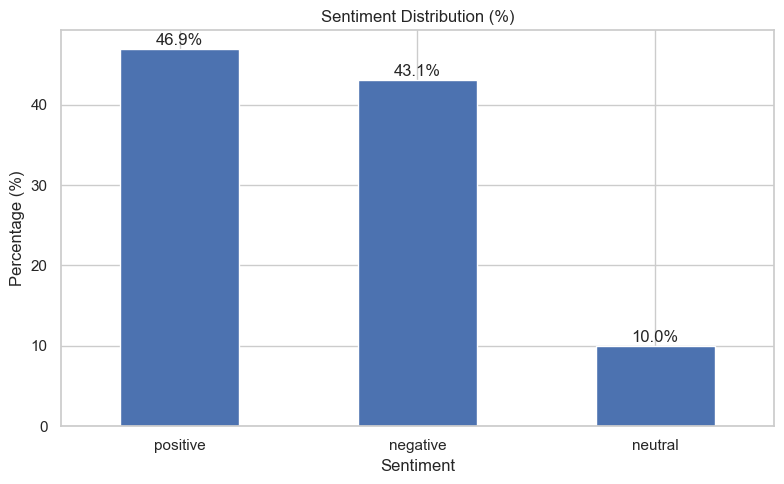

In [3]:
import matplotlib.pyplot as plt

sent_percent = sent_counts / sent_counts.sum() * 100

plt.figure(figsize=(8, 5))
sent_percent.plot(kind='bar')

plt.title("Sentiment Distribution (%)")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

for i, v in enumerate(sent_percent):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

Multi-aspect Distribution


SỐ LƯỢNG ASPECT TRUNG BÌNH MỖI BÌNH LUẬN: 1.6171487409903584
1    6185
2    3011
3    1037
4     314
5     114
6      22
Name: count, dtype: int64


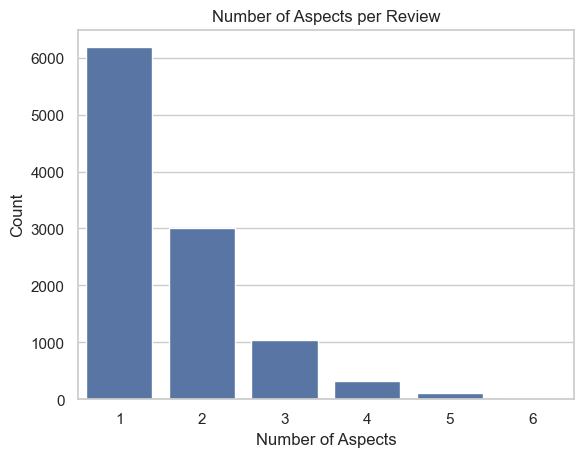

In [5]:
aspect_per_review = (
    (df_stats[target_aspects] != "none")
    .sum(axis=1)
)
print("\nSỐ LƯỢNG ASPECT TRUNG BÌNH MỖI BÌNH LUẬN:", aspect_per_review.mean())
print(aspect_per_review.value_counts().sort_index())
sns.countplot(x=aspect_per_review)
plt.title("Number of Aspects per Review")
plt.xlabel("Number of Aspects")
plt.ylabel("Count")
plt.show()

Aspect Co-occurrence Matrix: Aspect nào thường xuất hiện cùng nhau

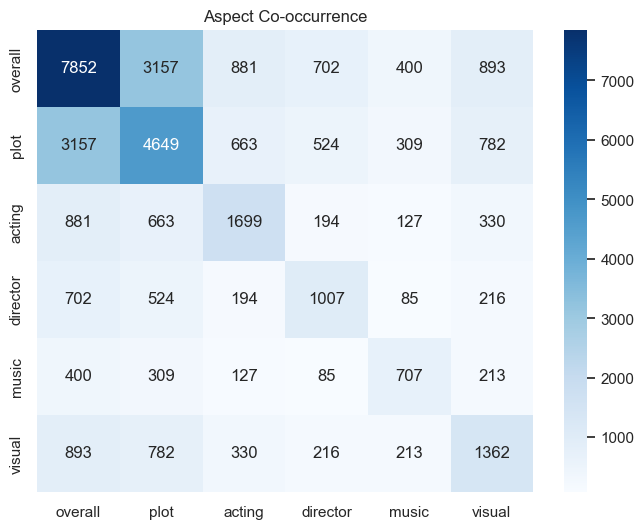

In [6]:
aspect_binary = (
    df_stats[target_aspects] != "none"
).astype(int)

co_matrix = aspect_binary.T.dot(aspect_binary)

plt.figure(figsize=(8,6))
sns.heatmap(
    co_matrix,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Aspect Co-occurrence")
plt.show()

In [15]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()

for _, row in df_stats.iterrows():

    present = [
        a for a in target_aspects
        if row[a] != "none"
    ]

    for pair in combinations(sorted(present),2):
        pair_counter[pair] += 1

print(pair_counter.most_common(10))

[(('overall', 'plot'), 3157), (('overall', 'visual'), 893), (('acting', 'overall'), 881), (('plot', 'visual'), 782), (('director', 'overall'), 702), (('acting', 'plot'), 663), (('director', 'plot'), 524), (('music', 'overall'), 400), (('acting', 'visual'), 330), (('music', 'plot'), 309)]


Độ dài review

count    10683.000000
mean        35.809230
std         44.163045
min          2.000000
25%         12.000000
50%         21.000000
75%         42.000000
max        436.000000
Name: length, dtype: float64


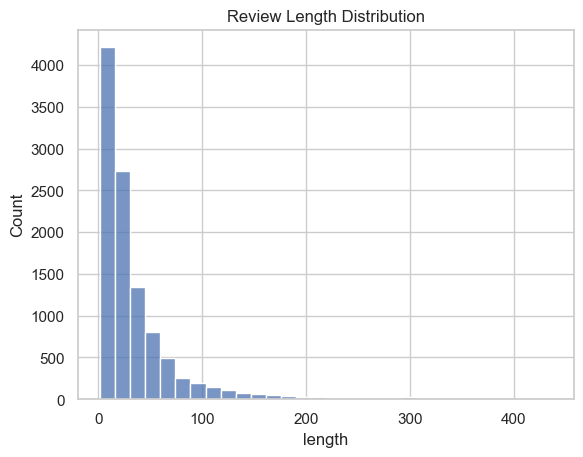

In [18]:
df_stats["length"] = (
    df_stats["text"]
    .astype(str)
    .str.split()
    .str.len()
)

print(df_stats["length"].describe())
sns.histplot(
    df_stats["length"],
    bins=30
)
plt.title("Review Length Distribution")
plt.show()